# PHT3D Example 4 — cation exchange

MF6PQC reproduction of the official PHT3D Example 4 breakthrough curves. The official numerical results are stored in `input_data/official_reference.npz`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

CASE_DIR = Path.cwd()
if CASE_DIR.name != "PHT3D_E04":
    CASE_DIR = CASE_DIR / "examples" / "PHT3D_E04"
sys.path.insert(0, str(CASE_DIR))

from plot_utils import (
    comparison_metrics,
    load_comparison,
    plot_official_style,
    plot_residuals,
    plot_species_panels,
)

plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 200})
pore_volumes, mf6pqc, pht3d = load_comparison(CASE_DIR)

## Official-style breakthrough comparison

Lines are MF6PQC and points are the official PHT3D UCN values at the outlet cell. Colors, axes, limits, species, and point/line convention follow the original Example 4 figure.

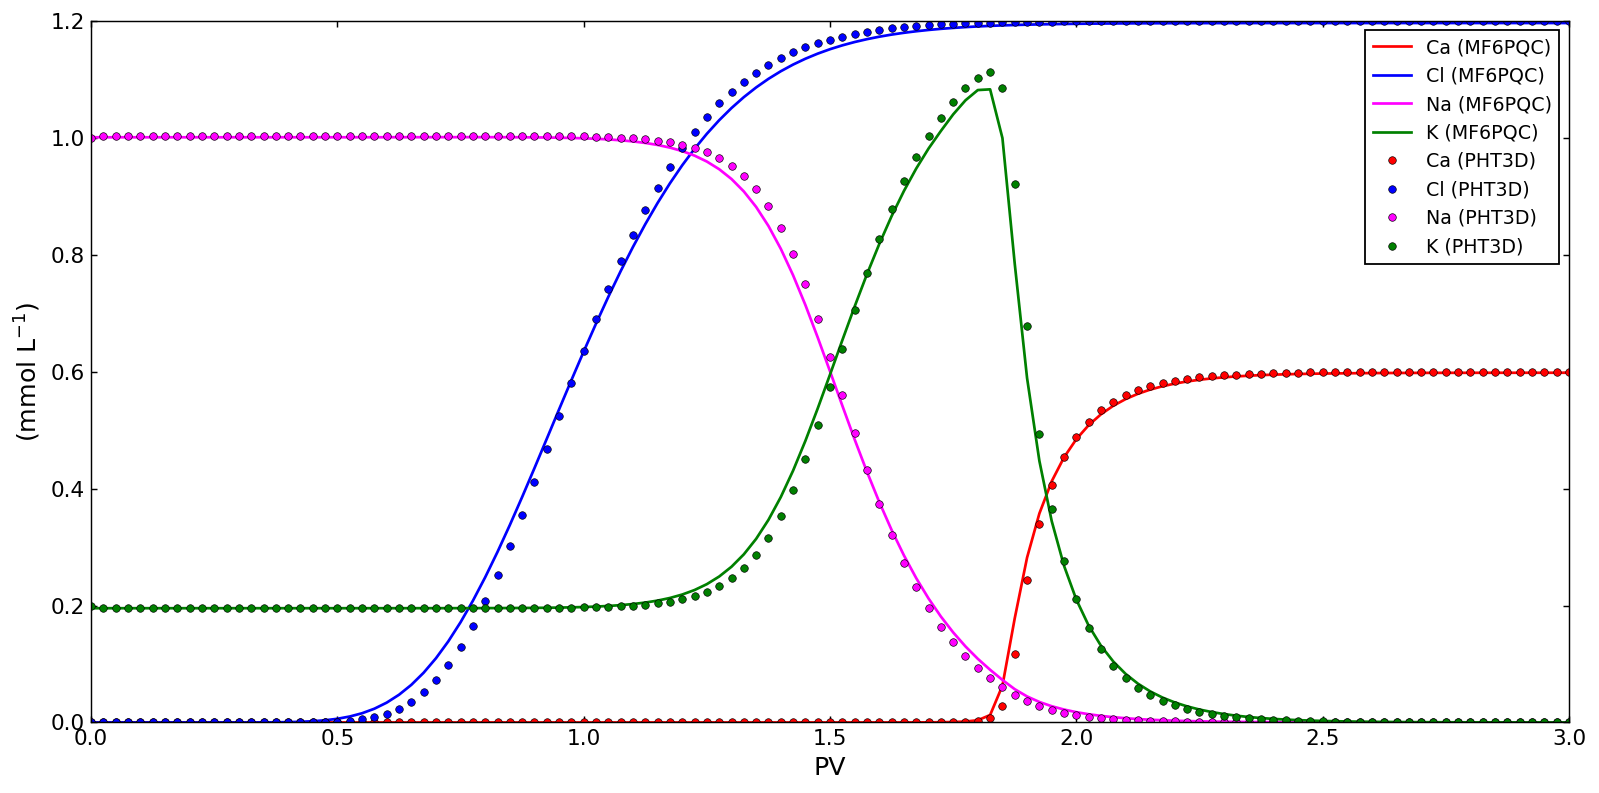

In [2]:
fig, ax = plot_official_style(pore_volumes, mf6pqc, pht3d)
plt.show()

## Species-by-species comparison

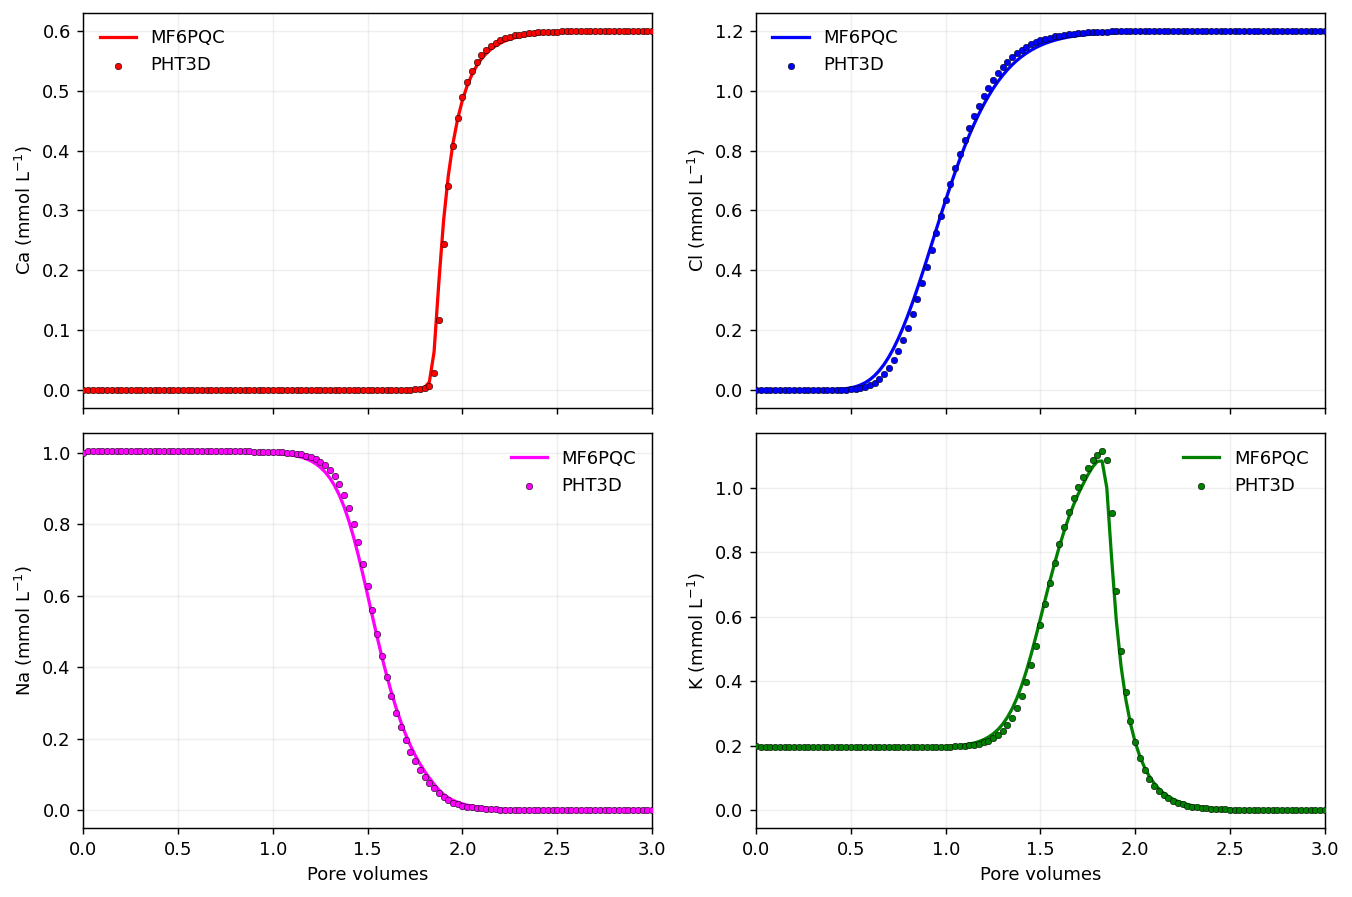

In [3]:
fig, axes = plot_species_panels(pore_volumes, mf6pqc, pht3d)
plt.show()

## Residuals and quantitative diagnostics

NRMSE is normalized by the official concentration range.

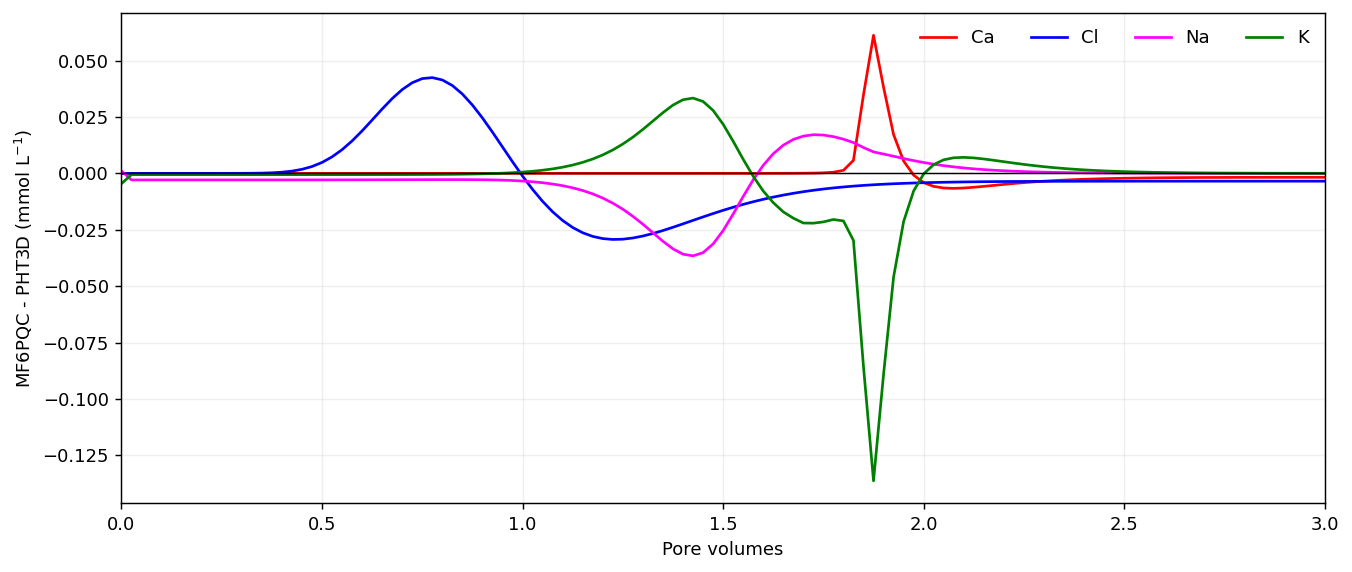

,RMSE (mmol/L),NRMSE,Max abs. error (mmol/L),Correlation
Ca,0.007750,0.012916,0.061191,0.999623
Cl,0.015518,0.012932,0.042427,0.999682
Na,0.010433,0.010391,0.036576,0.999815
K,0.020111,0.018072,0.136292,0.998073


In [4]:
fig, ax = plot_residuals(pore_volumes, mf6pqc, pht3d)
plt.show()

metrics = pd.DataFrame(comparison_metrics(mf6pqc, pht3d)).T
metrics